In [4]:
library(tidyverse)
source("../scripts/00_R_presets.R")

Warning message:
“package ‘ggplot2’ was built under R version 4.4.3”
── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.2     ✔ tibble    3.2.1
✔ lubridate 1.9.3     ✔ tidyr     1.3.1
✔ purrr     1.0.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors


## Figure 2

Ancestry, Variants, Genome Graph

- D: Ancestry variation Graph

In [8]:
# Load RepeatMasker data
rm_data <- read_csv("../../doc/tables/for_plots/repeatmasker_summary.all_samples.csv")

# Create sample groups
rm_data <- rm_data %>%
    mutate(
        group = case_when(
            grepl("^T2T", sample) ~ "T2T Samples",
            grepl("^HG", sample) ~ "Reference", 
            TRUE ~ "Other"
        )
    )

head(rm_data)

Rows: 1334 Columns: 7
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (3): sample, repeat_class, repeat_family
dbl (4): count, total_length, mean_length, mean_div

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


sample,repeat_class,repeat_family,count,total_length,mean_length,mean_div,group
<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
T2T00,DNA,Crypton,576,84401,146.5295,25.40868,T2T Samples
T2T00,DNA,Crypton-A,269,39008,145.0112,26.81933,T2T Samples
T2T00,DNA,Kolobok,720,118747,164.9264,24.98278,T2T Samples
T2T00,DNA,MULE-MuDR,5917,1944303,328.5961,18.14195,T2T Samples
T2T00,DNA,Merlin,441,75869,172.0385,21.29002,T2T Samples
T2T00,DNA,PIF-Harbinger,730,128138,175.5315,26.64685,T2T Samples


In [9]:
# Calculate genome percentages by repeat class
class_data <- rm_data %>%
    group_by(sample, group, repeat_class) %>%
    summarise(class_total = sum(total_length), .groups = "drop") %>%
    group_by(sample) %>%
    mutate(
        total_genome = sum(class_total),
        percentage = (class_total / total_genome) * 100
    ) %>%
    ungroup()

# Check the data
class_data %>% arrange(desc(percentage)) %>% head(10)

sample,group,repeat_class,class_total,total_genome,percentage
<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>
T2T16,T2T Samples,LINE,1256880477,3241055821,38.77997
T2T10,T2T Samples,LINE,1276138976,3302398054,38.64280
T2T01,T2T Samples,LINE,1253582620,3248475359,38.58988
T2T12,T2T Samples,LINE,1250842093,3244358666,38.55437
T2T15,T2T Samples,LINE,1253267888,3250695801,38.55383
T2T08,T2T Samples,LINE,1253429493,3255254398,38.50481
T2T13,T2T Samples,LINE,1258433338,3269104607,38.49474
T2T07,T2T Samples,LINE,1258899897,3278681296,38.39653
T2T00_2,T2T Samples,LINE,1298602496,3382916752,38.38707


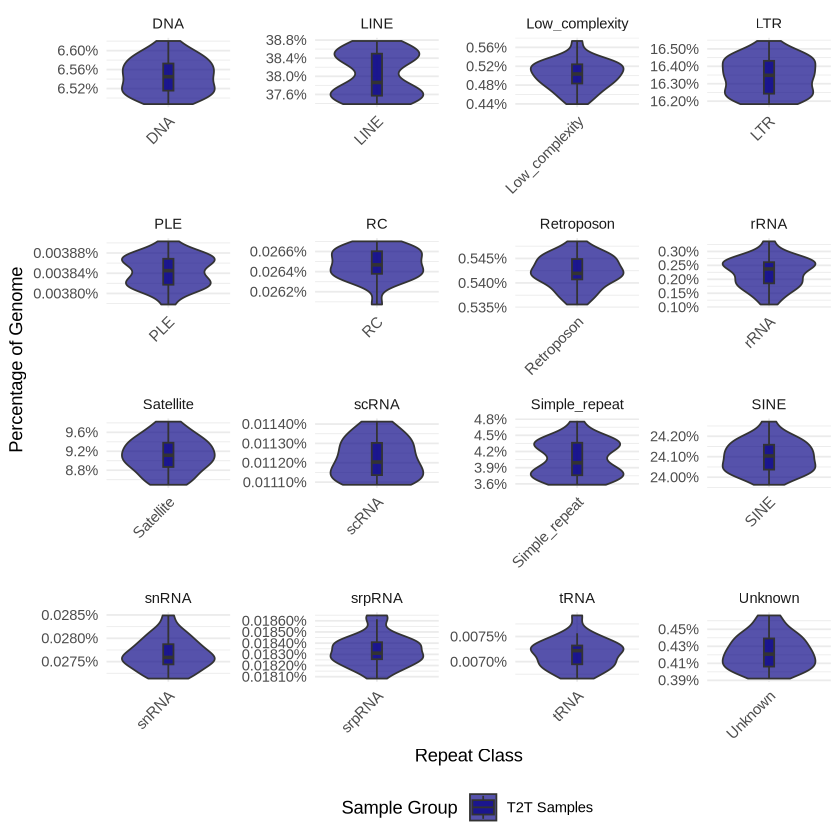

In [11]:
# Figure 2D: Repetitive Element Variation
fig2d_repeats <- ggplot(class_data, aes(x = fct_reorder(repeat_class, class_total, sum, .desc = TRUE), 
                                        y = percentage, fill = group)) +
    geom_violin(alpha = 0.7, position = position_dodge(width = 0.8)) +
    geom_boxplot(width = 0.1, position = position_dodge(width = 0.8), 
                 outlier.shape = NA, alpha = 0.8) +
    facet_wrap(~repeat_class, scales = "free", ) +
    scale_fill_viridis_d(name = "Sample Group", option = "C") +
    scale_y_continuous(labels = scales::percent_format(scale = 1)) +
    labs(
        x = "Repeat Class",
        y = "Percentage of Genome"
    ) +
    theme_minimal() +
    theme(
        axis.text.x = element_text(angle = 45, hjust = 1),
        legend.position = "bottom"
    )

fig2d_repeats